In [27]:
pip install ../..

Processing /Users/macbookair/program/projects/cascad_oc
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for cascadoc: filename=cascadoc-0.0.2-py3-none-any.whl size=55626 sha256=1caa6f705bed5e47195d21900e837b6d655d90cf6dda6015a459d8f235159d49
  Stored in directory: /private/var/folders/kw/gkm7_pzd2ys4xnvml76j1h2c0000gn/T/pip-ephem-wheel-cache-1ec6qh38/wheels/f1/a4/cd/883821fc2ec5b1be0bcb80a94463abeb7e0361d6c9a3656084
Successfully built cascadoc
  Attempting uninstall: cascadoc
    Found existing installation: cascadoc 0.0.2
    Uninstalling cascadoc-0.0.2:
      Successfully uninstalled cascadoc-0.0.2

[notice] A new release of pip is available: 25.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [5]:
from cascadoc_old import Mesh, Solver, HypProblem, solve_oc
import numpy as np
from time import time
import matplotlib.pyplot as plt



In [6]:
G11_true = lambda t: -(10*np.sin(10*t))/(np.cos(10*t)+np.sin(15*t)+4)
G22_true = lambda t: -(15*np.cos(15*t))/(4-np.cos(10*t)-np.sin(15*t))

x0 = lambda s: 2*(s-1/2)**3+1/2
y0 = lambda s: 1/2

x_an = lambda s, t: 2*np.cos(10*t)*(s-1/2)**3+1/2
y_an = lambda s, t: 2*np.sin(15*t)*(s-1/2)**3+1/2
T = [0, 0.5]
S = [0, 1]
C = [1,2]
# C = [2.3,0.9]
D = lambda t: np.cos(10*t)**2+np.sin(15*t)**2
B11 = lambda s, t: - (10*np.sin(10*t)*np.cos(10*t))/D(t)
B12 = lambda s, t: - (10*np.sin(10*t)*np.sin(15*t))/D(t)
B21 = lambda s, t:  (15*np.cos(15*t)*np.cos(10*t))/D(t)
B22 = lambda s, t:  (15*np.cos(15*t)*np.sin(15*t))/D(t)

G11 = lambda t: -(10*np.sin(10*t))/(np.cos(10*t)+np.sin(15*t)+4)
G12 = lambda t: G11(t)

G21 = lambda t: -(15*np.cos(15*t))/(4-np.cos(10*t)-np.sin(15*t))
G22 = lambda t: G21(t)

F1 = lambda s, t:-6*C[0]*np.cos(10*t)*(s-1/2)**2-(B11(s,t)+B12(s,t))/2
F2 = lambda s, t: 6*C[1]*np.sin(15*t)*(s-1/2)**2-(B21(s,t)+B22(s,t))/2

phi_dx = lambda s, x, y : -2*(x - x_an(s, T[1])) 
phi_dy = lambda s, x, y : -2*(y - y_an(s, T[1]))

hyp_problem = HypProblem(T=T, S=S, C=C, B=[[B11, B12], [B21, B22]], 
                         F=[F1, F2], G=[[G11, G12], [G21, G22]], 
                         X0=x0, Y0=y0, phi_dx=phi_dx, phi_dy=phi_dy)

mesh = Mesh(hyp_problem, 100)
solver = Solver()
solver.solve_initial(mesh, hyp_problem)
solver.solver_center(mesh, hyp_problem)
solver.solver_final(mesh, hyp_problem)

In [8]:
# Первое приближение ===============================================
# uk_0 = np.random.random(len(t_h))
# G22_0 = lambda t: np.int
G22_0 = lambda t: G22_true(t)
G21_0 = lambda t: G22_0(t)
hyp_problem.set_G([[G11, G12], [G21_0, G22_0]])

solver.solve_initial(mesh, hyp_problem)
solver.solver_center(mesh, hyp_problem)
solver.solver_final(mesh, hyp_problem)

In [9]:
def plot_mesh():
    plt.figure(figsize=(12,6))
    
    plt.subplot(3, 2, 1)
    mesh.plot_border(border_type='final', fun='x', style='r.')
    mesh.plot_border(border_type='final', fun=lambda si: x_an(si, T[1]), style="b-", fun_name='x_an')
    # plt.ylim([-0.5, 1.5])

    
    plt.subplot(3, 2, 3)
    mesh.plot_border(border_type='final', fun='y', style='r.')
    mesh.plot_border(border_type='final', fun=lambda si: y_an(si, T[1]), style="b-", fun_name='y_an')
    # plt.ylim([-0.5, 1.5])
    
    plt.subplot(3, 2, 2)
    mesh.plot_border(border_type='left', fun='x', style='r.')
    mesh.plot_border(border_type='left', fun=lambda ti: x_an(S[0], ti), style="b-", fun_name='x_an')
    plt.ylim([-0.5, 1.5])
    
    plt.subplot(3, 2, 4)
    mesh.plot_border(border_type='left', fun='y', style='r.')
    mesh.plot_border(border_type='left', fun=lambda ti: y_an(S[0], ti), style="b-", fun_name='y_an')
    plt.ylim([-0.5, 1.5])
    
    plt.subplot(3, 2, 6)
    mesh.plot_border(border_type='left', fun=lambda ti: G22_true(ti), style='b-', fun_name='v_an')
    mesh.plot_border(border_type='left', fun=lambda ti: hyp_problem.G22(ti), style='r.', fun_name='v')

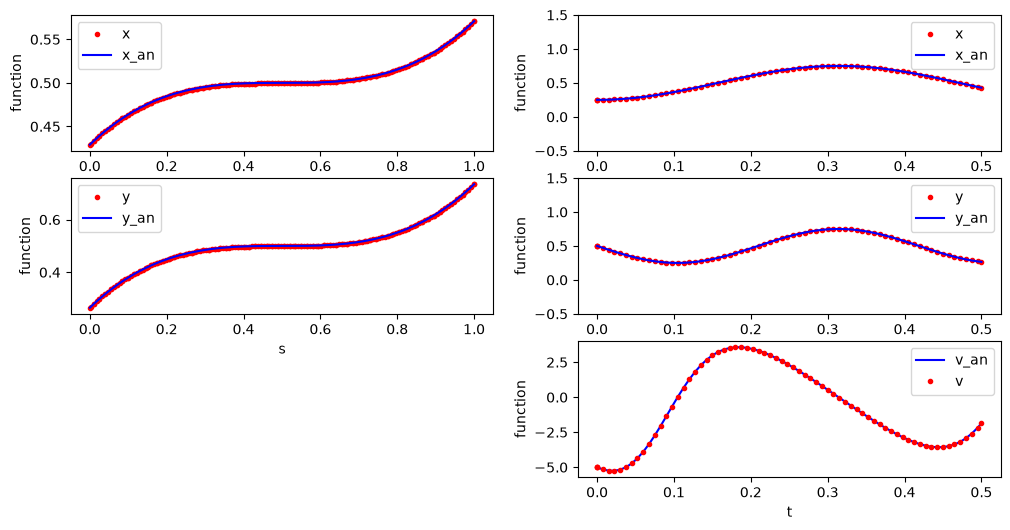

In [10]:
plot_mesh()


In [11]:
# ["mpm", "cgm", "impm"]
U0 = lambda t: G22_true(t)*0
xs = lambda s: x_an(s, T[1])
ys = lambda s: y_an(s, T[1])
start_time = time()
rez = solve_oc(hyp_problem, mesh, U0, xs, ys, u_lim=[-6, 6],  method= "cgm",
               eps=0.001, 
               beta = 0.0, 
               delta = 1.0, 
               eps_count_max=6,
               debug=True)
print(f"сек:{time()-start_time:.2f}")

****************************************[1 iter]
Не оптимально
Невязка составляет: 2.177380
****************************************
результат минимизации a =  0.045454545454545456
****************************************[2 iter]
Не оптимально
Невязка составляет: 1.879122
****************************************
результат минимизации a =  0.043478260869565216
****************************************[3 iter]
Не оптимально
Невязка составляет: 1.653030
****************************************
результат минимизации a =  0.041666666666666664
****************************************[4 iter]
Не оптимально
Невязка составляет: 1.464434
****************************************
результат минимизации a =  0.04
****************************************[5 iter]
Не оптимально
Невязка составляет: 1.296534
****************************************
результат минимизации a =  0.038461538461538464
****************************************[6 iter]
Не оптимально
Невязка составляет: 1.144912
*******************

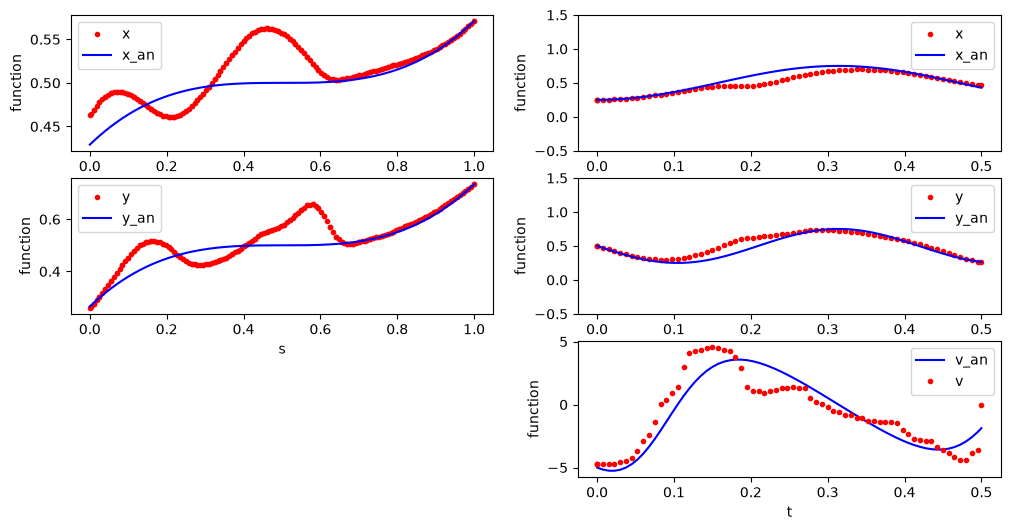

In [12]:
plot_mesh()


In [13]:
rezs = dict()
for method in ["mpm", "cgm", "impm"]:
    rezs[method] = dict()
    U0 = lambda t: G22_true(t)*0
    xs = lambda s: x_an(s, T[1])
    ys = lambda s: y_an(s, T[1])
    start_time = time()
    
    rezs[method]['solve_oc'] = solve_oc(hyp_problem, mesh, U0, xs, ys, u_lim=[-6, 6],  method= method,
                   eps=0.001, 
                   beta = 0.0, 
                   delta = 1.0, 
                   eps_count_max=6,
                   debug=True)
    rezs[method]['control'] = hyp_problem.G22(rezs[method]['solve_oc'].t_hash)
    rezs[method]['time'] =  time()-start_time

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 0.004530896884143849
        x: [ 1.077e+00 -0.000e+00 ... -1.037e-01 -1.620e-02]
      nit: 14
      jac: [-2.344e-05  0.000e+00 ...  4.026e-06  7.215e-07]
 hess_inv: [[ 1.939e+01  0.000e+00 ... -1.560e+00 -2.439e-01]
            [ 0.000e+00  1.000e+00 ...  0.000e+00  0.000e+00]
            ...
            [-1.560e+00  0.000e+00 ...  1.141e+00  2.211e-02]
            [-2.439e-01  0.000e+00 ...  2.211e-02  1.003e+00]]
     nfev: 1278
     njev: 18
****************************************[1 iter]
Не оптимально
Невязка составляет: 2.177380
****************************************
результат минимизации a =  0.045454545454545456
****************************************[2 iter]
Не оптимально
Невязка составляет: 1.879122
****************************************
результат минимизации a =  0.043478260869565216
****************************************[3 iter]
Не оптимально
Невязка составляет: 1.653030
*****

In [15]:
rezs_save = dict()
for method, d in rezs.items():
    rezs_save[method] = dict()
    rezs_save[method]['time'] = d['time']
    rezs_save[method]['control'] = d['control'].tolist()

In [16]:
import json

with open('rezs.json', 'w') as f:
    json.dump(rezs_save, f)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


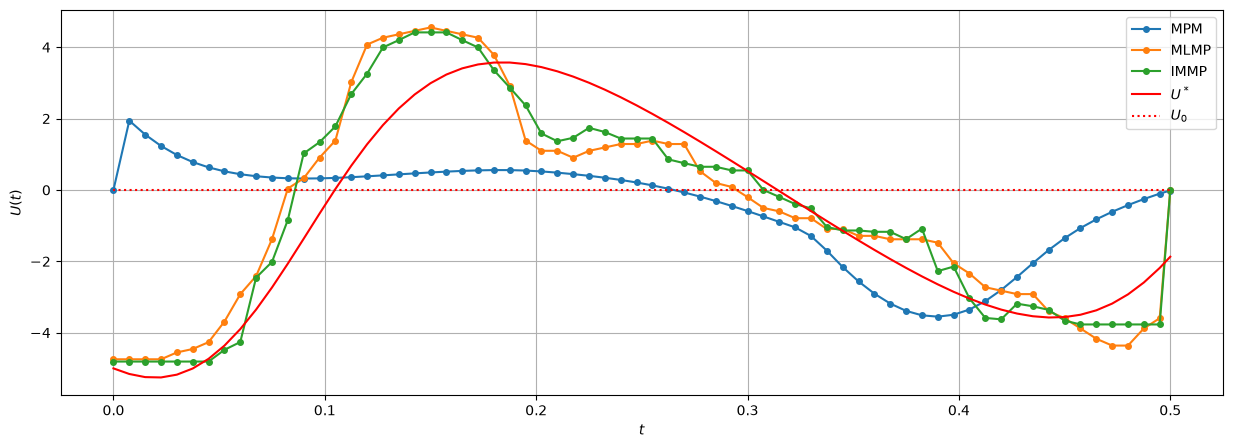

In [12]:
import json
with open('rezs.json', 'r') as f:
    rezs_save = json.load(f)

import matplotlib.pyplot as plt
plt.figure(figsize=(15,5))

nodes = mesh.get_border(type_border="left", sort_t=True)
t_mesh = [node[0][3] for node in nodes]
t_hash = []
for i, e in enumerate(t_mesh):
    if not e in t_hash:
        t_hash.append(e)
names = {
    'mpm': 'MPM',
    'cgm': 'MLMP',
    'impm': 'IMMP'
}
for method, d in rezs_save.items():
    plt.plot(t_hash, d['control'], '-o', markersize=4, label=names[method].upper())

plt.plot(t_hash, [G22_true(r) for r in t_hash], 'r', label='$U^*$')
plt.plot(t_hash, [G22_true(r)*0 for r in t_hash], 'r:', label='$U_0$')
plt.legend()
plt.xlabel('$t$')
plt.ylabel('$U(t)$')
plt.grid()
plt.savefig('methods.eps')

In [48]:
import scipy 

for method, d in rezs.items():
    solve_oc = d['solve_oc']
    control = d['control']
    solve_oc.set_new_control(lambda ti: np.interp(ti, solve_oc.t_hash, control))
    solve_oc.solve()
    
    nodes = solve_oc.mesh.get_border(type_border="final", sort_s=True)
    s_final = [node[0][2] for i, node in enumerate(nodes) if i in solve_oc.t_index]
    x_final = [node[1][0][0] for i, node in enumerate(nodes)if i in solve_oc.t_index]
    y_final = [node[1][0][1] for i, node in enumerate(nodes) if i in solve_oc.t_index]
    
    f = [(xi-solve_oc.xs(si))**2+(yi-solve_oc.ys(si))**2 for xi, yi, si in zip(x_final, y_final, s_final)]
    # for fi in f:
    #     print(f'{fi:.2f} ', end='')
    # print()
    print(method, scipy.integrate.trapezoid(f, s_final))



mpm 0.004683799119232389
cgm 0.0013268661225463829
impm 0.001285543095223155


In [11]:
!python --version

Python 3.13.2


Text(0, 0.5, 'residual')

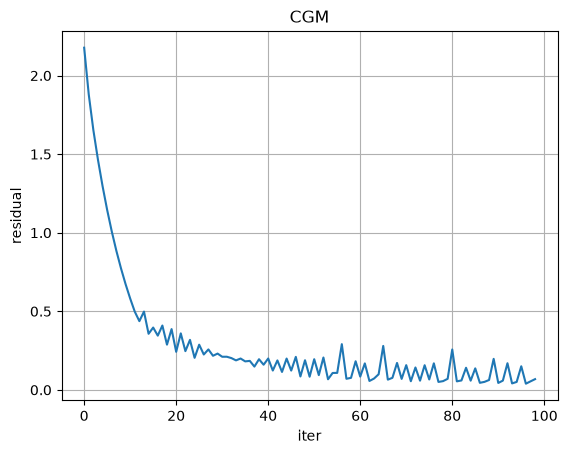

In [55]:
plt.title('CGM')
plt.plot(rezs['cgm']['solve_oc'].rezid)
plt.grid()
plt.xlabel('iter')
plt.ylabel('residual')

Text(0, 0.5, 'residual')

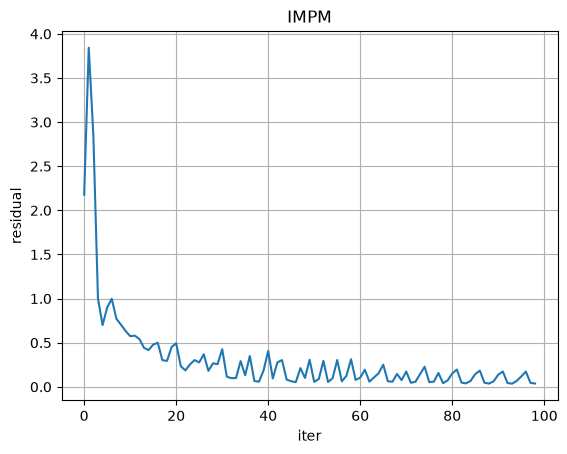

In [54]:
plt.title('IMPM')
plt.plot(rezs['impm']['solve_oc'].rezid)
plt.grid()
plt.xlabel('iter')
plt.ylabel('residual')

# Досчитываю

In [14]:
# ["mpm", "cgm", "impm"]
U0 = hyp_problem.G22
xs = lambda s: x_an(s, T[1])
ys = lambda s: y_an(s, T[1])
start_time = time()
rez = solve_oc(hyp_problem, mesh, U0, xs, ys, u_lim=[-6, 6],  method= "CGM",
               eps=0.001, 
               beta = 0.5, 
               delta = 0.8, 
               eps_count_max=6,
               debug=True)
print(f"сек:{time()-start_time:.2f}")

****************************************[1 iter]
Не оптимально
Невязка составляет: 4.665681
****************************************
результат минимизации a =  0.045454545454545456
****************************************[2 iter]
Не оптимально
Невязка составляет: 23.604119
****************************************
результат минимизации a =  0.03125
****************************************[3 iter]
Не оптимально
Невязка составляет: 9.663846
****************************************
результат минимизации a =  0.02702702702702703
****************************************[4 iter]
Не оптимально
Невязка составляет: 7.146244
****************************************
результат минимизации a =  0.025
****************************************[5 iter]
Не оптимально
Невязка составляет: 5.440518
****************************************
результат минимизации a =  0.024390243902439025
****************************************[6 iter]
Не оптимально
Невязка составляет: 3.645708
*******************************

KeyboardInterrupt: 

In [ ]:
plot_mesh()

AttributeError: 'function' object has no attribute 'copy'